In [1]:
import pandas as pd 
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [2]:
df = pd.read_parquet('../../data/raw/all_chicago_crimes.parquet')

In [3]:
X = df[['Primary Type', 'Description', 'Year', 'Beat', 'District', 'Ward', 'Location Description']]
y = df['Arrest']

enc = OneHotEncoder()

enc.fit(X)

X = enc.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.9)

In [4]:
model = LogisticRegression().fit(X_train, y_train)

In [5]:
model.score(X_test, y_test)

0.8877493338587406

In [6]:
categories = enc.categories_
total_list = [i for j in categories for i in j ]

In [7]:
categories_and_names = [[model.coef_[0][i], total_list[i]] for i in range(len(model.coef_[0]))]
cats_and_nam = {'category':[c[1] for c in categories_and_names], 'model_coef':[c[0] for c in categories_and_names]}
model_coef_df = pd.DataFrame(cats_and_nam).sort_values(by='model_coef', ascending=False)

<Axes: title={'center': 'Factors contributing the most to an arrest being made'}, ylabel='category'>

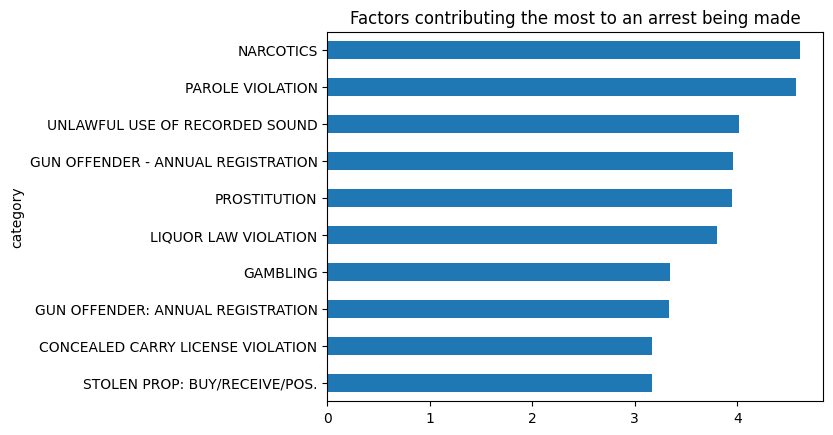

In [8]:
top_df = model_coef_df.iloc[0:10]
top_df.sort_values(by='model_coef').plot(kind='barh', x='category', y='model_coef', legend=False, title='Factors contributing the most to an arrest being made')

<Axes: title={'center': 'Factors contributing the most to an arrest not being made'}, ylabel='category'>

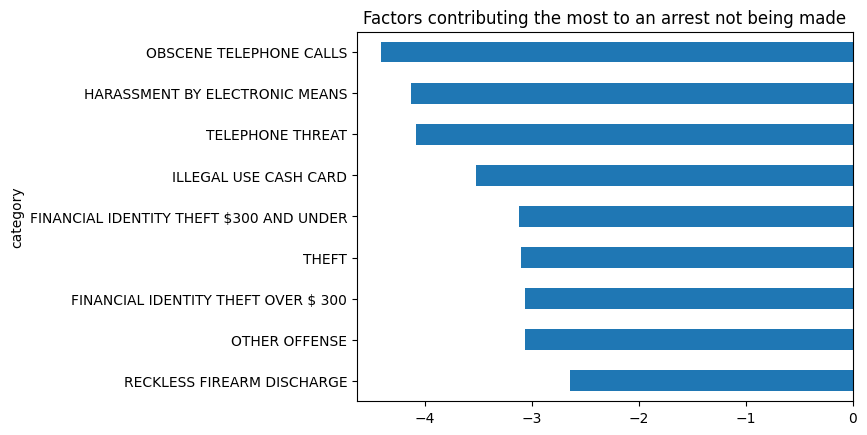

In [9]:
bottom_df = model_coef_df[-10:-1]
bottom_df.plot(kind='barh', x='category', y='model_coef', legend=False, title='Factors contributing the most to an arrest not being made')

<Axes: >

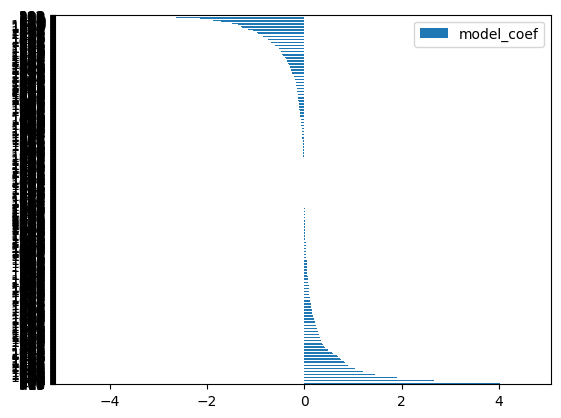

In [10]:
model_coef_df.plot(kind='barh')